In [1]:
from sklearn.datasets import make_regression
import matplotlib.pyplot as plt
import numpy as np

In [2]:
X, y = make_regression(n_samples=100, n_features=1, n_informative=1, n_targets=1, noise=20, random_state=13)

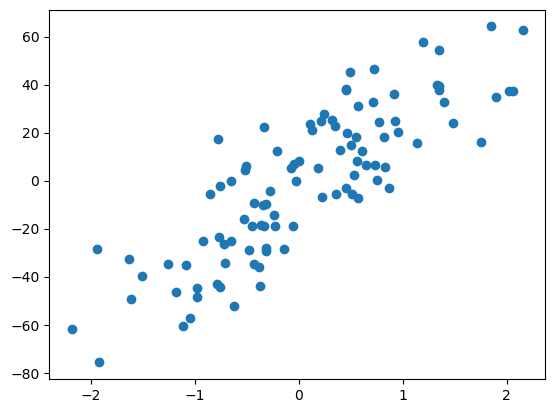

In [3]:
plt.scatter(X,y)

In [4]:
# Create 10 equally spaced values for slope (m) ranging from -150 to 150
m_arr = np.linspace(-150, 150, 10)

# Create 10 equally spaced values for intercept (b) ranging from -150 to 150
b_arr = np.linspace(-150, 150, 10)

# Generate all possible (m, b) combinations using a meshgrid
mGrid, bGrid = np.meshgrid(m_arr, b_arr)

# Flatten the meshgrid and combine slope & intercept values
# Result: a (100, 2) array where each row represents one (m, b) pair
final = np.vstack((mGrid.ravel().reshape(1, 100),
                   bGrid.ravel().reshape(1, 100))).T

# List to store the Sum of Squared Errors (SSE) for each (m, b) pair
z_arr = []

# Calculate the cost (SSE) for every combination of slope and intercept
for i in range(final.shape[0]):
    z_arr.append(
        np.sum(
            (y - final[i, 0] * X.reshape(100) - final[i, 1]) ** 2
        )
    )

# Convert the list of SSE values into a NumPy array
# Reshape it into a 10 × 10 grid to match the meshgrid dimensions
z_arr = np.array(z_arr).reshape(10, 10)

In [5]:
import plotly.graph_objects as go

# Create a 3D surface plot of the cost function
# x-axis  -> Slope (m)
# y-axis  -> Intercept (b)
# z-axis  -> Sum of Squared Errors (SSE)
fig = go.Figure(
    data=[
        go.Surface(
            x=m_arr,
            y=b_arr,
            z=z_arr
        )
    ]
)

# Customize the appearance of the plot
fig.update_layout(
    title='Cost Function',      # Title of the graph
    autosize=False,             # Disable automatic figure sizing
    width=500,                  # Width of the figure (in pixels)
    height=500,                 # Height of the figure (in pixels)
    margin=dict(
        l=65,                   # Left margin
        r=50,                   # Right margin
        b=65,                   # Bottom margin
        t=90                    # Top margin
    )
)

# Display the interactive 3D surface plot
fig.show()

# Save the interactive plot as an HTML file
# This file can be opened in any web browser
fig.write_html("cost_function.html")

In [7]:
# Initialize the intercept (b), slope (m), and learning rate
b = 150
m = -127.82
lr = 0.001

# Lists to store the parameter values and cost at each epoch
all_b = []
all_m = []
all_cost = []

# Number of times the algorithm will iterate over the entire dataset
epochs = 30

# Gradient Descent Loop
for i in range(epochs):

    # Initialize gradients for the current epoch
    slope_b = 0
    slope_m = 0

    # Initialize the cost (Sum of Squared Errors) for the current epoch
    cost = 0

    # Loop through each training example
    for j in range(X.shape[0]):

        # Compute the gradient with respect to the intercept (b)
        slope_b = slope_b - 2 * (y[j] - (m * X[j]) - b)

        # Compute the gradient with respect to the slope (m)
        slope_m = slope_m - 2 * (y[j] - (m * X[j]) - b) * X[j]

        # Calculate the squared error and accumulate it into the total cost
        cost = cost + (y[j] - (m * X[j]) - b) ** 2

    # Update the intercept using the computed gradient
    b = b - (lr * slope_b)

    # Update the slope using the computed gradient
    m = m - (lr * slope_m)

    # Store the updated parameters for visualization/analysis
    all_b.append(b)
    all_m.append(m)

    # Store the cost for the current epoch
    all_cost.append(cost)

In [8]:
import plotly.express as px
fig = px.scatter_3d(x = np.array(all_m).ravel(), y = np.array(all_b).ravel(), z = np.array(all_cost).ravel()*100)
fig.add_trace(go.Surface(x = m_arr, y = b_arr, z = z_arr * 100))
fig.show()

fig.write_html('cost_function2.html')

In [9]:
import plotly.graph_objects as go
fig = go.Figure(go.Scatter(x = np.array(all_m).ravel(), y = np.array(all_b).ravel(), name = 'High 2014', line = dict(color='#fff', width=4)))

fig.add_trace(go.Contour(z = z_arr, x = m_arr, y = b_arr))
fig.show()

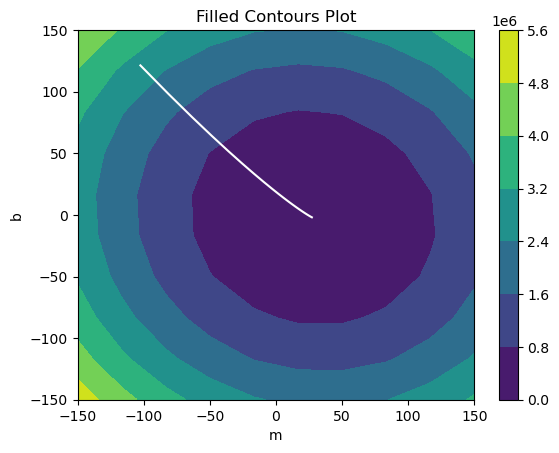

<Figure size 1800x400 with 0 Axes>

In [10]:
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1,1)
plt.figure(figsize=(18,4))
cp = ax.contourf(m_arr, b_arr, z_arr)
ax.plot(np.array(all_m).ravel(), np.array(all_b).ravel(), color='white')
fig.colorbar(cp) # Add a colorbar to a plot
ax.set_title('Filled Contours Plot')
ax.set_xlabel('m')
ax.set_ylabel('b')
plt.show()

In [16]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML, display

fig, axis = plt.subplots(figsize=(9, 5))
axis.set_xlim(-150, 150)
axis.set_ylim(-150, 150)

axis.contourf(m_arr, b_arr, z_arr)
line, = axis.plot([], [], lw=2, color='white')
xdata, ydata = [], []


def animate(i):
    label = f'epoch {i + 1}'
    xdata.append(all_m[i])
    ydata.append(all_b[i])

    line.set_data(xdata, ydata)
    axis.set_xlabel(label)

    return line,


anim = animation.FuncAnimation(fig, animate, frames=30, repeat=False, interval=500)
display(HTML(anim.to_jshtml()))


<IPython.core.display.Javascript object>